# Regional Clustering Analysis of Central Java Province

This notebook contains the clustering analysis of districts/cities in Central Java Province using education, economic, poverty, and demographic indicators. The analysis applies Hierarchical Clustering and K-Means Clustering to identify regional socio-economic patterns.

In [4]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [5]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving central_java_clustering_2024.xlsx to central_java_clustering_2024.xlsx


In [6]:
# Read files
df = pd.read_excel("central_java_clustering_2024.xlsx")
df.head()

,regency_city,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
0,Cilacap,7.40,67077,10.68,872
1,Banyumas,7.91,40151,11.95,1328
2,Purbalingga,7.36,32147,14.18,1288
3,Banjarnegara,6.87,27640,14.71,924
4,Kebumen,7.87,27288,15.71,1060


In [7]:
# Check the dataset size
df.shape

(35, 5)

In [8]:
# Check the dataset type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   regency_city         35 non-null     object 
 1   avg_years_schooling  35 non-null     float64
 2   grdp_per_capita      35 non-null     int64  
 3   poverty_rate         35 non-null     float64
 4   population_density   35 non-null     int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 1.5+ KB


In [9]:
# Check the missing value
df.isnull().sum()

,0
regency_city,0
avg_years_schooling,0
grdp_per_capita,0
poverty_rate,0
population_density,0


In [10]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# Descriptive statistics
df.describe()

,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
count,35.000000,35.000000,35.000000,35.000000
mean,8.320857,51366.685714,10.128571,2053.771429
std,1.375355,33174.804058,3.211398,2419.549485
min,6.410000,22631.000000,4.030000,187.000000
25%,7.380000,30617.000000,7.555000,917.000000
50%,7.870000,38775.000000,9.630000,1141.000000
75%,9.270000,54310.000000,11.995000,1776.500000
max,11.480000,156570.000000,15.710000,11302.000000


In [12]:
# Separate region names and numeric variables
region_names = df["regency_city"]
X = df.drop(columns=["regency_city"])

X.head()

,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
0,7.40,67077,10.68,872
1,7.91,40151,11.95,1328
2,7.36,32147,14.18,1288
3,6.87,27640,14.71,924
4,7.87,27288,15.71,1060


In [13]:
# Data standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
0,-0.679316,0.480475,0.174217,-0.495557
1,-0.303089,-0.343014,0.575457,-0.304341
2,-0.708824,-0.587804,1.279996,-0.321114
3,-1.070297,-0.725643,1.447443,-0.473752
4,-0.332597,-0.736409,1.763380,-0.416722


In [14]:
# Combine the standardization results with the region names
scaled_df = pd.concat([region_names.reset_index(drop=True), X_scaled_df], axis=1)

scaled_df.head()

,regency_city,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
0,Cilacap,-0.679316,0.480475,0.174217,-0.495557
1,Banyumas,-0.303089,-0.343014,0.575457,-0.304341
2,Purbalingga,-0.708824,-0.587804,1.279996,-0.321114
3,Banjarnegara,-1.070297,-0.725643,1.447443,-0.473752
4,Kebumen,-0.332597,-0.736409,1.763380,-0.416722


In [15]:
# Save the preprocessed dataset
df.to_csv("cleaned_central_java_clustering_2024.csv", index=False)
scaled_df.to_csv("standardized_central_java_clustering_2024.csv", index=False)

In [16]:
# Download the preprocessed dataset
from google.colab import files

files.download("cleaned_central_java_clustering_2024.csv")
files.download("standardized_central_java_clustering_2024.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Hierarchical clustering using Ward linkage
linkage_matrix = linkage(X_scaled, method="ward")

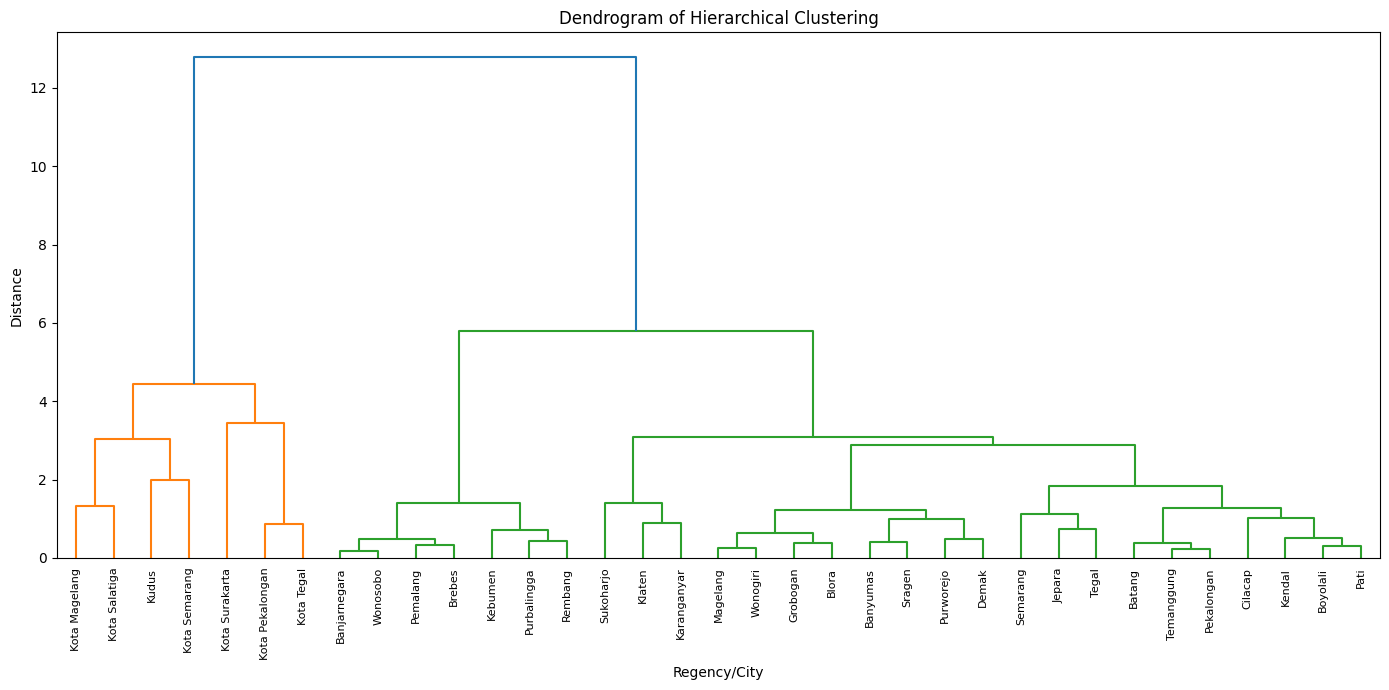

In [19]:
# Dendrogram visualization
plt.figure(figsize=(14, 7))

dendrogram(
    linkage_matrix,
    labels=region_names.values,
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Dendrogram of Hierarchical Clustering")
plt.xlabel("Regency/City")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [27]:
# Evaluate hierarchical clustering using silhouette score
silhouette_scores_hc = {}

for k in range(2, 7):
    labels = fcluster(linkage_matrix, k, criterion="maxclust")
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_hc[k] = score
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.5898
k = 3, Silhouette Score = 0.4041
k = 4, Silhouette Score = 0.3929
k = 5, Silhouette Score = 0.4006
k = 6, Silhouette Score = 0.3714


In [21]:
# Assign hierarchical clustering labels
hc_labels = fcluster(linkage_matrix, 2, criterion="maxclust")

# Add labels to original dataframe
df["hc_cluster"] = hc_labels

df.head()

,regency_city,avg_years_schooling,grdp_per_capita,poverty_rate,population_density,hc_cluster
0,Cilacap,7.40,67077,10.68,872,2
1,Banyumas,7.91,40151,11.95,1328,2
2,Purbalingga,7.36,32147,14.18,1288,2
3,Banjarnegara,6.87,27640,14.71,924,2
4,Kebumen,7.87,27288,15.71,1060,2


In [22]:
# Display members of each hierarchical cluster
for cluster in sorted(df["hc_cluster"].unique()):
    print(f"\nCluster {cluster}:")
    print(df[df["hc_cluster"] == cluster]["regency_city"].to_list())


Cluster 1:
['Kudus', 'Kota Magelang', 'Kota Surakarta', 'Kota Salatiga', 'Kota Semarang', 'Kota Pekalongan', 'Kota Tegal']

Cluster 2:
['Cilacap', 'Banyumas', 'Purbalingga', 'Banjarnegara', 'Kebumen', 'Purworejo', 'Wonosobo', 'Magelang', 'Boyolali', 'Klaten', 'Sukoharjo', 'Wonogiri', 'Karanganyar', 'Sragen', 'Grobogan', 'Blora', 'Rembang', 'Pati', 'Jepara', 'Demak', 'Semarang', 'Temanggung', 'Kendal', 'Batang', 'Pekalongan', 'Pemalang', 'Tegal', 'Brebes']


In [23]:
# Cluster profile based on original variables
hc_profile = df.groupby("hc_cluster")[
    ["avg_years_schooling", "grdp_per_capita", "poverty_rate", "population_density"]
].mean()

hc_profile

,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
hc_cluster,,,,
1,10.454286,104160.571429,6.347143,6059.571429
2,7.787500,38168.214286,11.073929,1052.321429


In [30]:
# Export the hierarchical clustering results
df.to_csv("hierarchical_clustering_result.csv", index=False)
files.download("hierarchical_clustering_result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

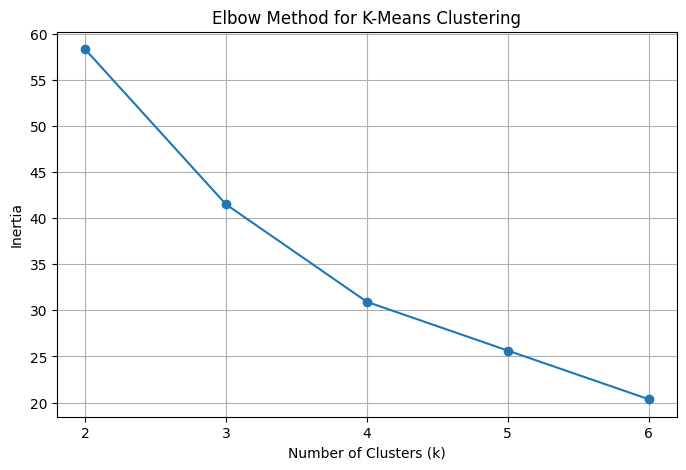

In [31]:
# Elbow Method for K-Means
inertia_values = []

K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker="o")
plt.title("Elbow Method for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [32]:
# Evaluate K-Means using Silhouette Score
silhouette_scores_kmeans = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores_kmeans[k] = score
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.5898
k = 3, Silhouette Score = 0.4041
k = 4, Silhouette Score = 0.3921
k = 5, Silhouette Score = 0.4006
k = 6, Silhouette Score = 0.3331


In [33]:
# Assign K-Means clustering labels
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans_final.fit_predict(X_scaled) + 1

df.head()

,regency_city,avg_years_schooling,grdp_per_capita,poverty_rate,population_density,hc_cluster,kmeans_cluster
0,Cilacap,7.40,67077,10.68,872,2,1
1,Banyumas,7.91,40151,11.95,1328,2,1
2,Purbalingga,7.36,32147,14.18,1288,2,1
3,Banjarnegara,6.87,27640,14.71,924,2,1
4,Kebumen,7.87,27288,15.71,1060,2,1


In [34]:
# Display members of each K-Means cluster
for cluster in sorted(df["kmeans_cluster"].unique()):
    print(f"\nCluster {cluster}:")
    print(df[df["kmeans_cluster"] == cluster]["regency_city"].to_list())


Cluster 1:
['Cilacap', 'Banyumas', 'Purbalingga', 'Banjarnegara', 'Kebumen', 'Purworejo', 'Wonosobo', 'Magelang', 'Boyolali', 'Klaten', 'Sukoharjo', 'Wonogiri', 'Karanganyar', 'Sragen', 'Grobogan', 'Blora', 'Rembang', 'Pati', 'Jepara', 'Demak', 'Semarang', 'Temanggung', 'Kendal', 'Batang', 'Pekalongan', 'Pemalang', 'Tegal', 'Brebes']

Cluster 2:
['Kudus', 'Kota Magelang', 'Kota Surakarta', 'Kota Salatiga', 'Kota Semarang', 'Kota Pekalongan', 'Kota Tegal']


In [35]:
# Cluster profile based on original variables
kmeans_profile = df.groupby("kmeans_cluster")[
    ["avg_years_schooling", "grdp_per_capita", "poverty_rate", "population_density"]
].mean()

kmeans_profile

,avg_years_schooling,grdp_per_capita,poverty_rate,population_density
kmeans_cluster,,,,
1,7.787500,38168.214286,11.073929,1052.321429
2,10.454286,104160.571429,6.347143,6059.571429


In [36]:
# Davies-Bouldin Index for Hierarchical and K-Means
db_hc = davies_bouldin_score(X_scaled, df["hc_cluster"])
db_kmeans = davies_bouldin_score(X_scaled, df["kmeans_cluster"])

print(f"Davies-Bouldin Index - Hierarchical: {db_hc:.4f}")
print(f"Davies-Bouldin Index - K-Means: {db_kmeans:.4f}")

Davies-Bouldin Index - Hierarchical: 0.7242
Davies-Bouldin Index - K-Means: 0.7242


In [39]:
# PCA for K-Means visualization
from sklearn.decomposition import PCA

# Reduce standardized data into 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["regency_city"] = region_names.values
pca_df["kmeans_cluster"] = df["kmeans_cluster"].values

pca_df.head()

,PC1,PC2,regency_city,kmeans_cluster
0,-0.441163,-0.254219,Cilacap,1
1,-0.753068,0.202978,Banyumas,1
2,-1.435687,0.690130,Purbalingga,1
3,-1.853466,0.693770,Banjarnegara,1
4,-1.577550,0.995760,Kebumen,1


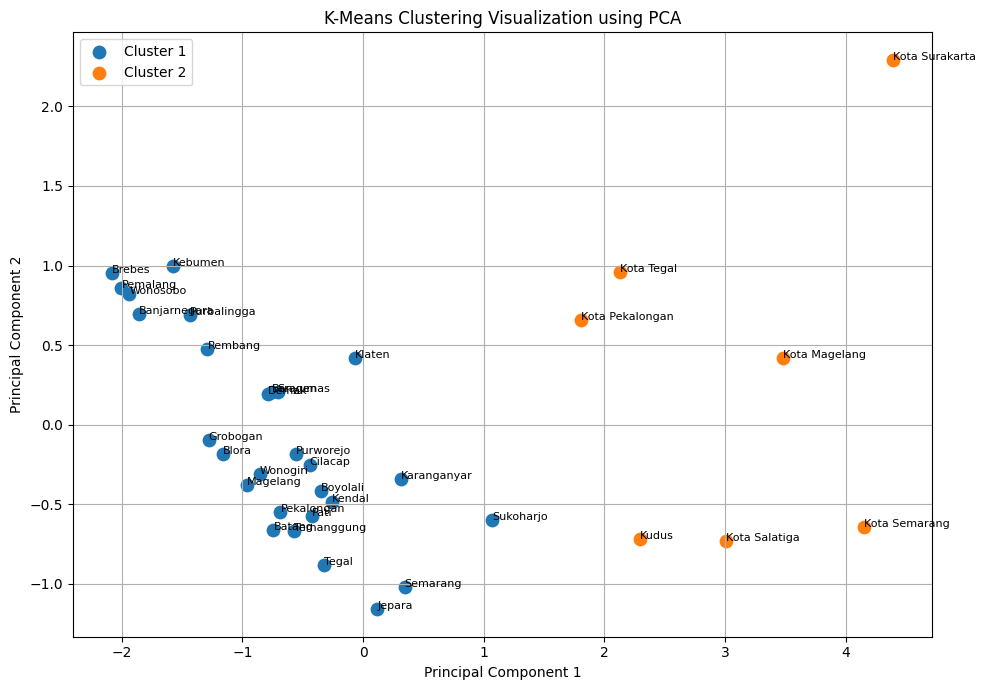

In [40]:
# Plot K-Means Cluster
plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["kmeans_cluster"].unique()):
    cluster_data = pca_df[pca_df["kmeans_cluster"] == cluster]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        s=80
    )

for i in range(len(pca_df)):
    plt.text(
        pca_df.loc[i, "PC1"],
        pca_df.loc[i, "PC2"],
        pca_df.loc[i, "regency_city"],
        fontsize=8
    )

plt.title("K-Means Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

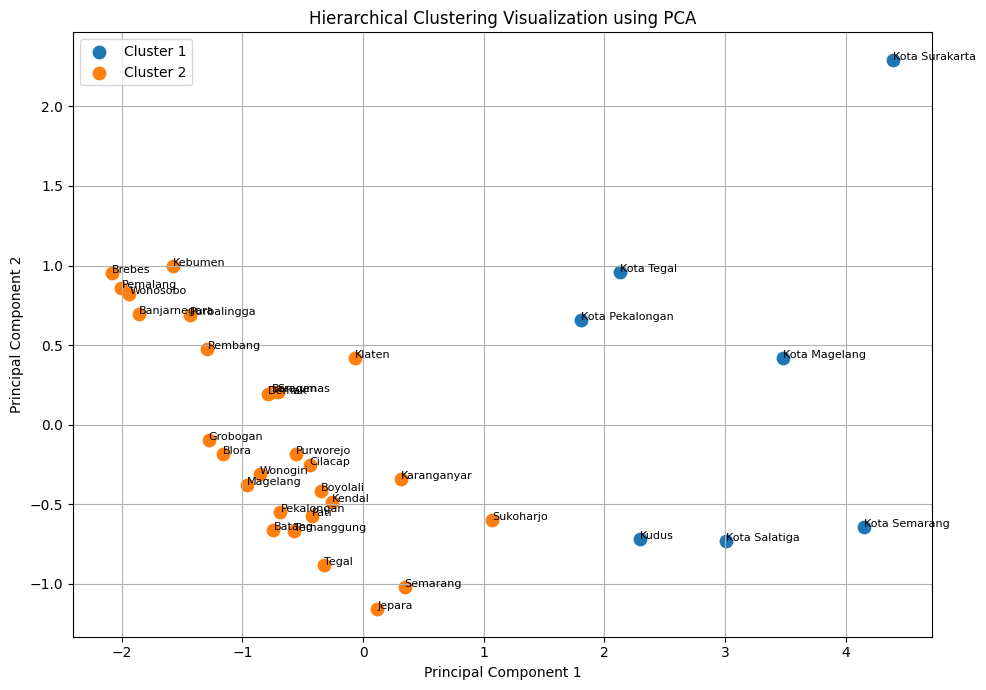

In [41]:
# Plot Hierarchical Clusters Using PCA
pca_df["hc_cluster"] = df["hc_cluster"].values

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["hc_cluster"].unique()):
    cluster_data = pca_df[pca_df["hc_cluster"] == cluster]
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        s=80
    )

for i in range(len(pca_df)):
    plt.text(
        pca_df.loc[i, "PC1"],
        pca_df.loc[i, "PC2"],
        pca_df.loc[i, "regency_city"],
        fontsize=8
    )

plt.title("Hierarchical Clustering Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
# Evaluation of final clustering results
silhouette_hc = silhouette_score(X_scaled, df["hc_cluster"])
silhouette_kmeans = silhouette_score(X_scaled, df["kmeans_cluster"])

db_hc = davies_bouldin_score(X_scaled, df["hc_cluster"])
db_kmeans = davies_bouldin_score(X_scaled, df["kmeans_cluster"])

print(f"Silhouette Score - Hierarchical Clustering: {silhouette_hc:.4f}")
print(f"Silhouette Score - K-Means Clustering: {silhouette_kmeans:.4f}")
print(f"Davies-Bouldin Index - Hierarchical Clustering: {db_hc:.4f}")
print(f"Davies-Bouldin Index - K-Means Clustering: {db_kmeans:.4f}")

Silhouette Score - Hierarchical Clustering: 0.5898
Silhouette Score - K-Means Clustering: 0.5898
Davies-Bouldin Index - Hierarchical Clustering: 0.7242
Davies-Bouldin Index - K-Means Clustering: 0.7242


In [43]:
# Export final clustering result
df.to_csv("central_java_final_clustering_results.csv", index=False)

from google.colab import files
files.download("central_java_final_clustering_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>